# 00 — Data Exploration & Preprocessing
## Credit Risk Classification

This notebook prepares the dataset that every other notebook in
`notebooks/` builds on. The goal is to understand the data well
enough to justify the modeling choices used consistently across all the
algorithm notebooks: **Logistic Regression, KNN, Naive Bayes, Decision Tree,
SVM, Random Forest** and **Gradient Boosting / XGBoost**.

**Dataset:** `german_credit_data.csv` — 1,000 loan applications from the
Statlog (German Credit) dataset, each described by demographic and loan
attributes (age, job type, housing, account balances, loan amount, duration,
purpose) and labelled `good` or `bad` according to whether the borrower
turned out to be a sound credit risk.

## Feature descriptions

Each row is one loan applicant. Nine predictors describe the applicant and
the loan; `Risk` is the outcome label.

| Column | Description | Type |
| --- | --- | --- |
| `Age` | Applicant's age | years |
| `Sex` | `male` / `female` | categorical |
| `Job` | Skill level: 0 = unskilled & non-resident, 1 = unskilled & resident, 2 = skilled, 3 = highly skilled / self-employed | ordinal 0-3 |
| `Housing` | `own`, `rent`, or `free` (living rent-free, e.g. with family) | categorical |
| `Saving accounts` | Balance band of savings account: `little`, `moderate`, `quite rich`, `rich`, or missing | categorical |
| `Checking account` | Balance band of checking account: `little`, `moderate`, `rich`, or missing | categorical |
| `Credit amount` | Size of the requested loan | Deutsche Mark |
| `Duration` | Repayment period of the loan | months |
| `Purpose` | What the loan is for (car, radio/TV, education, business, ...) | categorical |
| `Risk` | **Target.** `good` = loan repaid as agreed, `bad` = borrower defaulted / went delinquent | binary |

**A note on `Sex`:** in a real lending system, using a protected attribute
like sex as a model input is a legal and ethical problem, not just a
technical one. It is kept here because it is part of the historical
benchmark dataset and because the fairness discussion is worth having — but
the honest reading of any coefficient or importance score attached to it is
"this is what the historical data encodes", not "this is a valid basis for a
lending decision".

## Why `bad` is the positive class

The target is already binary, so unlike an ordinal score there is nothing to
collapse. The choice that *does* matter is **which class we call positive
(`1`)**, because precision, recall and F1 are all defined relative to it.

We use:

- `y = 1` if `Risk == "bad"` — the applicant is a **credit risk**
- `y = 0` if `Risk == "good"`

The rare, costly class is the one worth detecting, and that is the defaulter.
Framed this way, **recall** answers the question the lender actually cares
about — "of all the borrowers who went bad, how many did we flag?" — and
**precision** answers "of the applicants we rejected, how many really would
have defaulted?". With `good` as the positive class, both metrics would be
dominated by the easy majority and would tell us much less.

This framing also makes the **decision threshold** a real business lever
rather than a technicality: a false negative (approving a loan that
defaults) costs the lender the outstanding principal, while a false positive
(declining a customer who would have repaid) costs only the foregone
interest. Those are not the same number, so `0.5` is almost certainly not
the right cutoff — which is what the threshold-tuning section in notebooks
01-07 examines. Note that those sections pick the cutoff on the test set,
which is leakage; each one carries a caveat explaining how the choice would
actually be made in production.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/german_credit_data.csv", index_col=0)
print(df.shape)
df.head()

(1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


In [4]:
# describe() only covers the numeric columns; look at the categorical ones too.
for col in df.select_dtypes("object"):
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False), end="\n\n")

--- Sex ---
Sex
male      690
female    310
Name: count, dtype: int64

--- Housing ---
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

--- Saving accounts ---
Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

--- Checking account ---
Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

--- Purpose ---
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

--- Risk ---
Risk
good    700
bad     300
Name: count, dtype: int64



## Missing values & duplicates

First check: missing data and exact duplicate rows. Missing values would force
an imputation strategy (mean/median, or a model-based imputer), and duplicates
can quietly bias the train/test split if a duplicated row lands on both sides
of it.


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nExact duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Exact duplicate rows: 0


No duplicate rows, but two columns carry a lot of "missing" data: `Saving
accounts` (183 rows) and `Checking account` (394 rows).

What matters before handling them is **what kind of missingness this is**. The
mundane explanation is age — applicants too young to have opened an account
would show up as blanks, and the "missing" group would then skew young. If that
held, the blank would be a proxy for youth and would deserve very different
treatment from a real category.

The age distribution per account level settles it.


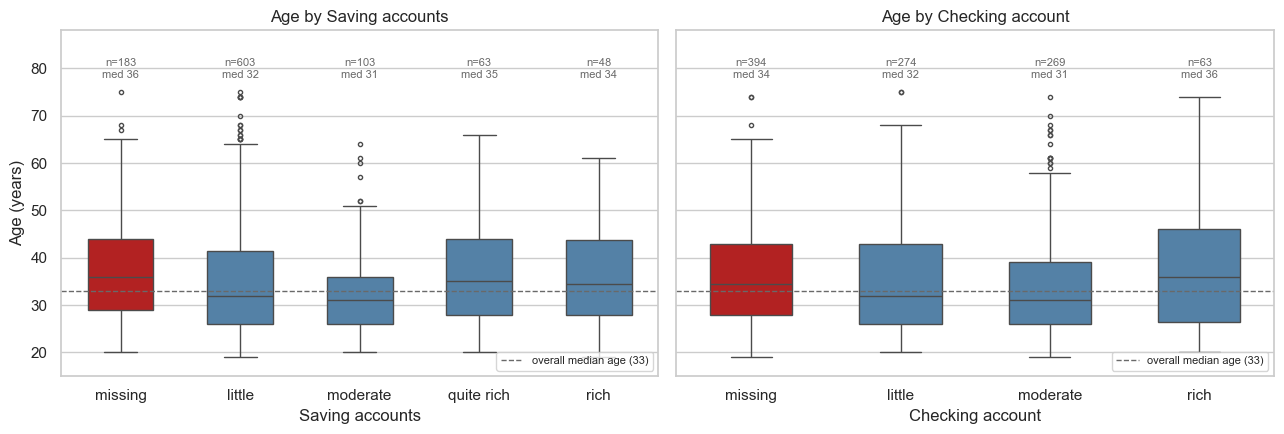

Applicants under 21: 16  (youngest in the dataset: 19)


,count,median,mean
Checking account,,,
little,274,32.0,35.3
missing,394,34.5,36.4
moderate,269,31.0,34.1
rich,63,36.0,37.2


In [6]:
# Hypothesis: the blanks are young applicants who have not opened an account yet.
# If so, the "missing" group should skew younger than the groups with a balance band.
orders = {
    "Saving accounts": ["missing", "little", "moderate", "quite rich", "rich"],
    "Checking account": ["missing", "little", "moderate", "rich"],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (col, order) in zip(axes, orders.items()):
    levels = df[col].fillna("missing")
    sns.boxplot(x=levels, y=df["Age"], order=order, ax=ax, width=0.55,
                color="steelblue", linewidth=1, fliersize=3)
    ax.patches[0].set_facecolor("firebrick")  # highlight the blank level
    ax.axhline(df["Age"].median(), color="dimgray", ls="--", lw=1,
               label=f"overall median age ({df['Age'].median():.0f})")
    for i, lvl in enumerate(order):
        grp = df.loc[levels == lvl, "Age"]
        ax.text(i, 78, f"n={len(grp)}\nmed {grp.median():.0f}", ha="center",
                fontsize=8, color="dimgray")
    ax.set_title(f"Age by {col}")
    ax.set_xlabel(col)
    ax.set_ylim(15, 88)
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("Age (years)")
plt.tight_layout()
plt.show()

print(f"Applicants under 21: {(df['Age'] < 21).sum()}  (youngest in the dataset: {df['Age'].min()})")
df.groupby(df["Checking account"].fillna("missing"))["Age"].agg(["count", "median", "mean"]).round(1)

The age explanation does not survive contact with the data. The blank group is
if anything the **oldest** — median age 36 for the missing `Saving accounts`
group and 34 for missing `Checking account`, against an overall median of 33 —
and the 99 applicants missing *both* accounts average 39 years old versus 35
for everyone else. There is also no pool of teenagers to blame: the youngest
applicant is 19 and only 16 people in the whole dataset are under 21, nowhere
near enough to account for 394 blank checking accounts.

So these are **not missing measurements, and not an age artefact.** In the
source dataset the blank is a real category — the applicant simply holds no
savings/checking account *at this bank*. The pattern that does show up is
occupational rather than generational: 42% of skilled workers (`Job == 2`) have
no checking account here versus 14% of the unskilled non-resident group, which
fits people who bank somewhere else rather than people with no money.

Imputing these with a mode would destroy genuine information, so we give the
blank its own level, `"none"`, and let the model decide what it is worth. As the
bad-rate breakdown below shows, that decision matters a lot: "no checking
account" turns out to be one of the *safest* groups in the data, not the
riskiest.

In [7]:
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

print(df[["Saving accounts", "Checking account"]].isna().sum())

Saving accounts     0
Checking account    0
dtype: int64


## Target distribution

The dataset is **imbalanced**: roughly 70% of the loans are `good` and 30%
are `bad`. That has two consequences we carry through every later notebook.

First, **accuracy is a misleading headline metric here.** A model that
ignores its inputs entirely and always predicts "good" scores 70% accuracy
while catching zero defaulters. So we track precision, recall, F1 and
ROC-AUC throughout, and read accuracy only alongside them.

Second, the default `0.5` probability cutoff will be **conservative about
predicting `bad`** — with only 30% of the training data in that class, a
model has to be quite confident before `P(bad) >= 0.5`. Rather than
rebalancing the training data (SMOTE) or reweighting the loss
(`class_weight="balanced"`), the algorithm notebooks handle this at the
**decision threshold**, which addresses the same problem at the point where
the cost tradeoff actually lives, and which can be moved along the
precision/recall curve after the fact instead of requiring a retrain.
`class_weight` is noted in each notebook as the alternative lever.

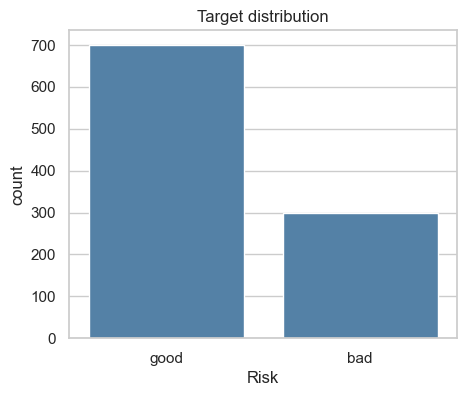

Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

In [8]:
y = (df["Risk"] == "bad").astype(int)

plt.figure(figsize=(5, 4))
sns.countplot(x=df["Risk"], order=["good", "bad"], color="steelblue")
plt.title("Target distribution")
plt.show()

df["Risk"].value_counts(normalize=True).rename("proportion")

## Which applicants go bad?

A per-category **bad rate** — the share of applicants in each group that
defaulted — is the cheapest check on whether the categorical features carry
signal at all, and in which direction.


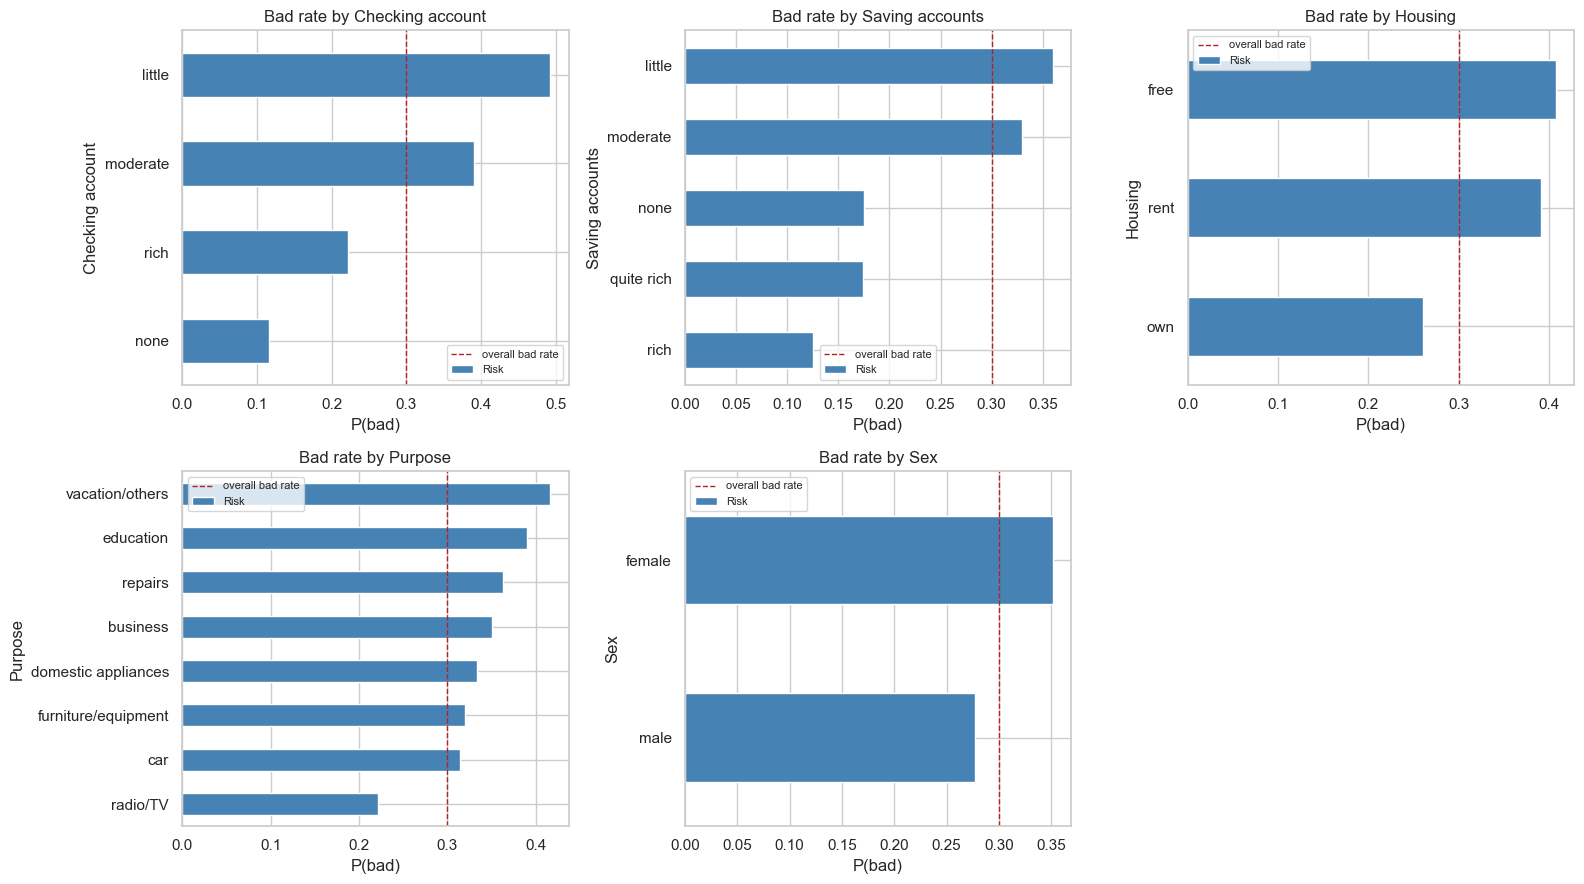

In [9]:
cat_cols = ["Checking account", "Saving accounts", "Housing", "Purpose", "Sex"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rates = df.groupby(col, observed=True)["Risk"].apply(lambda s: (s == "bad").mean()).sort_values()
    rates.plot(kind="barh", ax=ax, color="steelblue")
    ax.axvline(y.mean(), color="firebrick", ls="--", lw=1, label="overall bad rate")
    ax.set_title(f"Bad rate by {col}")
    ax.set_xlabel("P(bad)")
    ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

`Checking account` is by far the strongest single predictor, and it behaves
in a way a naive encoding would get badly wrong: applicants with **no**
checking account default at ~12%, *below* even the `rich` group, while those
with a `little` balance default at ~49%. Having no account at this bank is
evidently a marker of a customer who banks (and borrows) elsewhere, not of a
customer with no money.

The numeric features tell a simpler story: defaulters ask for **larger loans
over longer terms**, and skew slightly younger.

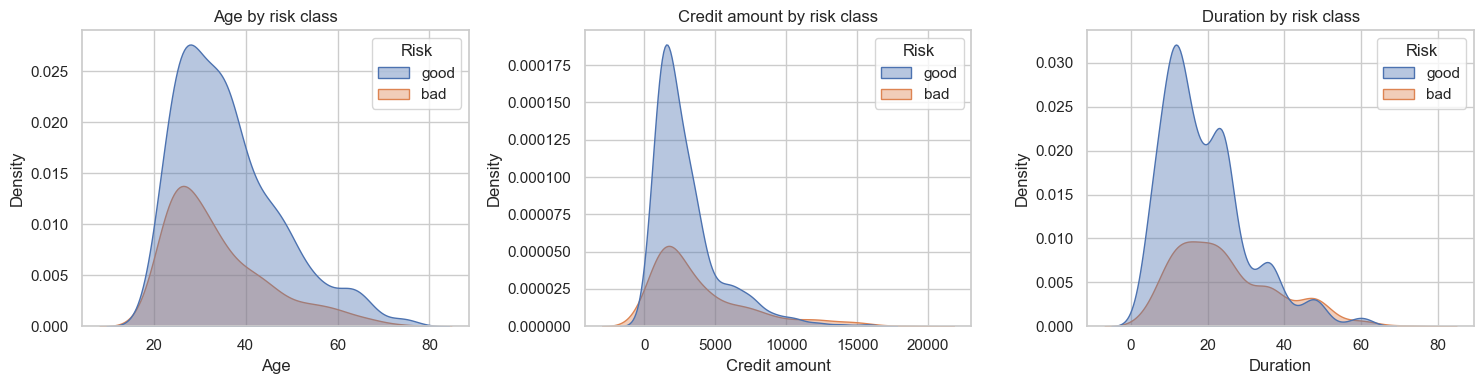

,Age,Credit amount,Duration
Risk,,,
bad,34.0,3938.1,24.9
good,36.2,2985.5,19.2


In [11]:
num_cols = ["Age", "Credit amount", "Duration"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue="Risk", hue_order=["good", "bad"], fill=True, alpha=0.4, ax=ax)
    ax.set_title(f"{col} by risk class")
plt.tight_layout()
plt.show()

df.groupby("Risk")[num_cols].mean().round(1)

## Encoding the categorical features

Six of the nine predictors are non-numeric, and every algorithm in this
folder needs numbers. Two encodings are in play:

- **`Job` stays as-is.** It is already an integer `0-3` with a meaningful
  order (unskilled non-resident → highly skilled), so the numbers carry real
  information.
- **Everything else is one-hot encoded** into 0/1 indicator columns, with
  `drop_first=True` to avoid the dummy-variable trap (a full set of `k`
  dummies is perfectly collinear — one column is implied by the others,
  which makes linear-model coefficients unidentifiable).

It is tempting to *ordinal*-encode `Saving accounts` and `Checking account`
instead, since `little < moderate < rich` is a genuine ordering and it would
cost fewer columns. The bad-rate plot above is why we don't: the `none`
level has no place on that scale — it is not "less than little", and forcing
it to the bottom would feed the model a relationship that runs backwards
from reality. One-hot encoding imposes no ordering and lets the model learn
each level's effect independently.

The `Purpose` column has 8 levels, several of them rare (`domestic
appliances` appears 12 times). One-hot encoding those produces columns with
very few 1s — noisy, and a candidate for grouping into an "other" bucket on
a larger project. We keep them separate here so nothing is hidden from the
models.

In [12]:
CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]

X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

print(f"{df.shape[1] - 1} raw predictors -> {X.shape[1]} encoded features")
X.head()

9 raw predictors -> 21 encoded features


,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_none,Saving accounts_quite rich,...,Checking account_moderate,Checking account_none,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67.0,2.0,1169.0,6.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,22.0,2.0,5951.0,48.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,49.0,1.0,2096.0,12.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,45.0,2.0,7882.0,42.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,53.0,2.0,4870.0,24.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature distributions

The three continuous features are **right-skewed** (`Credit amount`
especially — a long tail of large loans) and live on wildly different
scales: `Credit amount` runs into the thousands while the one-hot columns
are 0/1. This is important context for later notebooks: distance-based and
gradient-based models (KNN, SVM, Logistic Regression) are sensitive to
feature scale and will need `StandardScaler`; tree-based models (Decision
Tree, Random Forest, Gradient Boosting) split on one feature at a time and
are scale-invariant, so they don't.

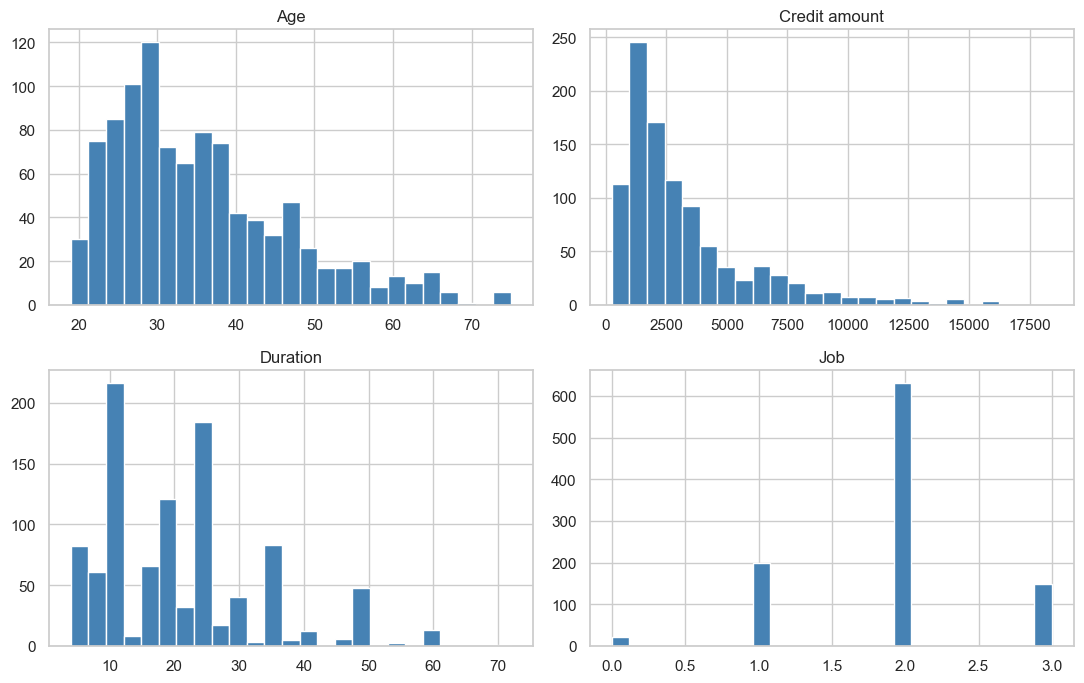

Age              1.020739
Credit amount    1.949628
Duration         1.094184
Name: skew, dtype: float64

In [16]:
df[num_cols + ["Job"]].hist(figsize=(11, 7), bins=25, color="steelblue")
plt.tight_layout()
plt.show()

df[num_cols].skew().rename("skew")

## Correlation analysis

The correlation heatmap covers two things:

1. Which features correlate (even weakly) with the target — a sanity check
   that the features carry signal at all.
2. **Multicollinearity** between features. The one-hot columns of a single
   original variable are mutually exclusive and therefore negatively
   correlated by construction, and `Credit amount` and `Duration` move
   together because bigger loans are repaid over longer terms. This matters
   mainly for linear models like Logistic Regression, where correlated
   features make individual coefficients unstable and hard to interpret, even
   though it costs little predictive accuracy.


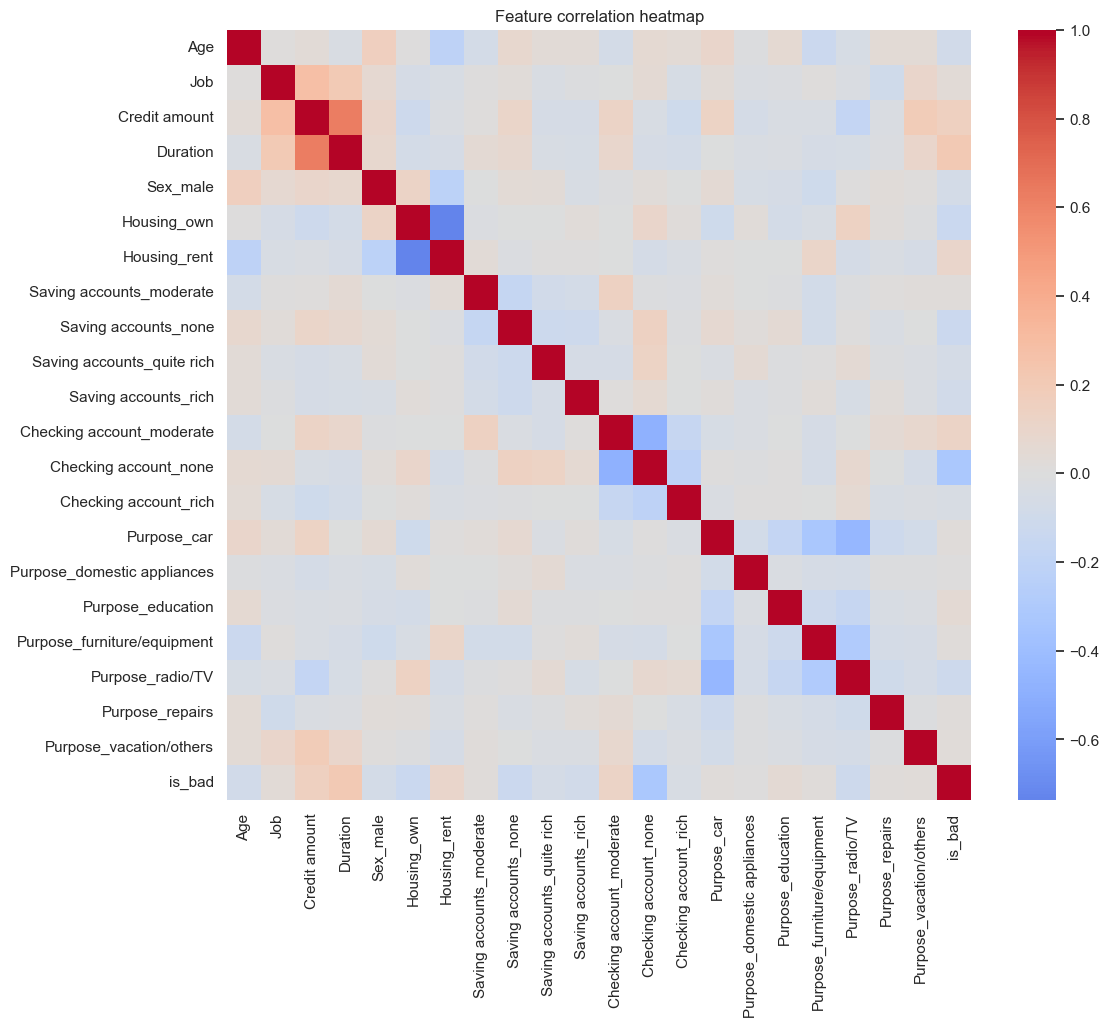

Checking account_none       -0.322436
Duration                     0.214927
Credit amount                0.154739
Housing_own                 -0.134589
Saving accounts_none        -0.129238
Checking account_moderate    0.119581
Purpose_radio/TV            -0.106922
Housing_rent                 0.092785
Age                         -0.091127
Saving accounts_rich        -0.085749
Name: corr with is_bad, dtype: float64

In [17]:
plt.figure(figsize=(12, 10))
corr = X.assign(is_bad=y).corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

X.corrwith(y).sort_values(key=abs, ascending=False).head(10).rename("corr with is_bad")

Not having a checking account, longer `Duration`, and larger `Credit amount`
show the strongest linear relationships with default — consistent with the
bad-rate breakdown above. Every individual correlation is modest (the
largest is around 0.3), which sets expectations for the rest of the project:
this is a genuinely hard problem where no single feature separates the
classes, and ROC-AUC in the 0.7-0.8 range is a realistic target rather than
a disappointment.

## Train/test split strategy

Every notebook in this folder uses the **exact same split**, so that model
comparisons across notebooks are apples-to-apples:

- `test_size=0.2` — 20% held out purely for final evaluation.
- `random_state=42` — fixed seed for reproducibility.
- `stratify=y` — preserves the 70/30 class balance in both the train and
  test sets. This matters more here than on a balanced dataset: without
  stratification, a random split of only 1,000 rows could easily hand the
  test set a noticeably different default rate than the training set,
  making the final metrics reflect the split rather than the model.

**Data leakage note:** any preprocessing that *learns* something from the
data (e.g. `StandardScaler.fit`, or a hyperparameter search) must be fit on
the training set only, then applied to the test set. Each algorithm notebook
follows this rule explicitly. The encoding above is safe to do up front
because `get_dummies` on these columns learns nothing from the target — but
note that on new production data it would need the same column set pinned,
since an unseen `Purpose` value would silently change the feature matrix.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train shape: (800, 21), Test shape: (200, 21)

Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64

Test class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


## Summary — conventions reused across every notebook in this folder

- **Data:** `../data/german_credit_data.csv`, loaded with `index_col=0`.
- **Missing values:** the blanks in `Saving accounts` / `Checking account`
  mean "no such account" and become their own `"none"` level — never imputed.
- **Target:** `y = (Risk == "bad")`, so **1 = bad credit risk** is the
  positive class, at a ~30% base rate.
- **Encoding:** `Job` kept ordinal; `Sex`, `Housing`, `Saving accounts`,
  `Checking account` and `Purpose` one-hot encoded with `drop_first=True`.
- **Split:** `train_test_split(test_size=0.2, random_state=42, stratify=y)`.
- **Scaling:** applied per-notebook, fit on train only, for models that need
  it (Logistic Regression, KNN, SVM); skipped for tree-based models.
- **Evaluation:** precision, recall, F1 and ROC-AUC on the `bad` class — not
  accuracy alone, which the 70/30 imbalance makes easy to fake.

Each algorithm notebook (`01`-`07`) repeats the short data prep snippet above
so it can be run standalone, then dedicates most of its content to that
algorithm's theory, its regularization knob(s), hyperparameter tuning via
cross-validation, and decision-threshold tuning. `08_model_comparison.ipynb`
ties all seven tuned models together at the end.